# The Price is Right

### Week 7 Day 2

Selecting our model and evaluating the base model against the task.

Keep in mind: our base model has 8 billion params, quantized down to 4 bits
Compared with GPT-5 at TRILLIONS of params!

In [3]:
# !pip install -q --upgrade bitsandbytes

In [4]:
!wget -q https://raw.githubusercontent.com/ed-donner/llm_engineering/main/week7/util.py -O util.py

In [5]:
# imports

import os
import re
import math
from tqdm import tqdm
# from google.colab import userdata
from huggingface_hub import login
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, set_seed
from peft import LoraConfig, PeftModel
from datasets import load_dataset, Dataset, DatasetDict
from datetime import datetime
import matplotlib.pyplot as plt
from util import evaluate
import sys
print(f"Python executable: {sys.executable}")
print(f"torch: {torch.__version__}")
print(f"torch.version.cuda: {torch.version.cuda}")
print(f"cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"device: {torch.cuda.get_device_name(0)}")

Python executable: /data/Projects/llm_engineering/.venv/bin/python
torch: 2.13.0.dev20260521+cu130
torch.version.cuda: 13.0
cuda available: True
device: NVIDIA GB10


In [6]:
# Constants

BASE_MODEL = "meta-llama/Llama-3.2-3B"
PROJECT_NAME = "price"

LITE_MODE = True

DATA_USER = "ed-donner"
DATASET_NAME = f"{DATA_USER}/items_prompts_lite" if LITE_MODE else f"{DATA_USER}/items_prompts_full"

# Hyper-parameters

QUANT_4_BIT = True

### Log in to HuggingFace

If you don't already have a HuggingFace account, visit https://huggingface.co to sign up and create a token.

Then select the Secrets for this Notebook by clicking on the key icon in the left, and add a new secret called `HF_TOKEN` with the value as your token.

In [7]:
# Log in to HuggingFace

# hf_token = userdata.get('HF_TOKEN')
# login(hf_token, add_to_git_credential=True)

import os
from dotenv import load_dotenv
from huggingface_hub import login

# .env laden
load_dotenv()

# Token aus .env lesen
hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN wurde nicht in der .env Datei gefunden")

# HuggingFace Login
login(token=hf_token, add_to_git_credential=True)

Token has not been saved to git credential helper.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


# Load our data

We uploaded it to Hugging Face, so it's easy to retrieve it now

In [8]:
dataset = load_dataset(DATASET_NAME)
train = dataset['train']
val = dataset['val']
test = dataset['test']

In [9]:
train[0]

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  \nCategory: Home Hardware  \nBrand: Schlage  \nDescription: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  \nDetails: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.\n\nPrice is $',
 'completion': '64.00'}

# Prepare our Base Llama Model for evaluation

Load our base model with 4 bit quantization and try out 1 example

In [10]:
## pick the right quantization

if QUANT_4_BIT:
  quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
  )
else:
  quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.bfloat16
  )

In [11]:
# Load the Tokenizer and the Model

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id

print(f"Memory footprint: {base_model.get_memory_footprint() / 1e9:.1f} GB")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/data/Projects/llm_engineering/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Memory footprint: 2.2 GB


In [12]:
def model_device(model):
    embeddings = model.get_input_embeddings()
    if embeddings is not None:
        return embeddings.weight.device
    return next(model.parameters()).device

def model_predict(item):
    inputs = tokenizer(item["prompt"], return_tensors="pt").to(model_device(base_model))
    with torch.no_grad():
        output_ids = base_model.generate(**inputs, max_new_tokens=8)
    prompt_len = inputs["input_ids"].shape[1]
    generated_ids = output_ids[0, prompt_len:]
    return tokenizer.decode(generated_ids)

In [13]:
test[0]

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.\n\nPrice is $',
 'completion': '219.0'}

In [14]:
model_predict(test[0])

/data/Projects/llm_engineering/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


"159.99, and it's available"

# Evaluation!

Trying out our base Llama 3.2 model against the Test dataset

In [15]:
evaluate(model_predict, test)

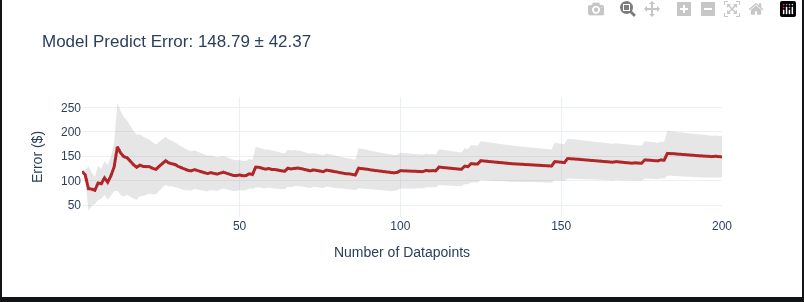

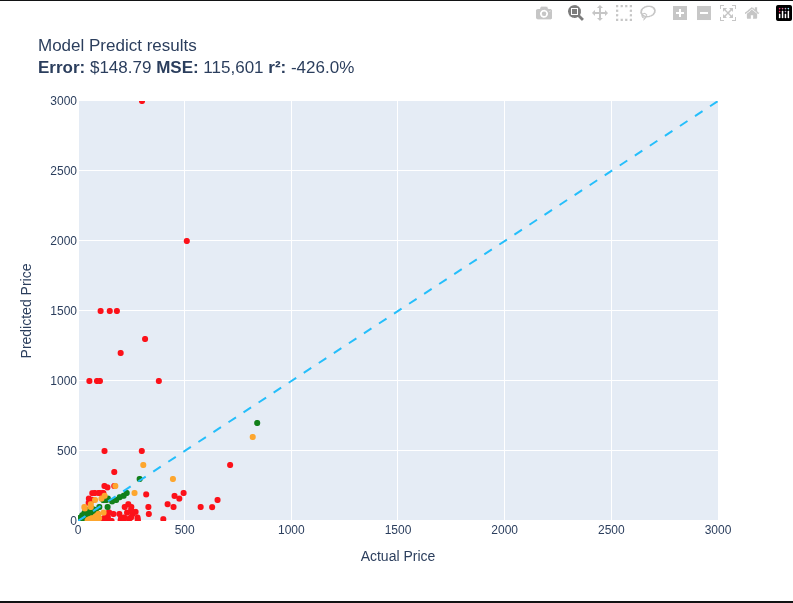